# Round 3 â€” Velvetfruit Extract + Vouchers

Replicates last-year (Volcanic Rock) analysis structure on this year's analogous products:

| Last year | This year |
|-----------|-----------|
| Volcanic Rock | `VELVETFRUIT_EXTRACT` (VE) |
| VR Vouchers 9500/9750/10000/10250/10500 | `VEV_4000..VEV_6500` (10 strikes) |

**Plots**
1. Underlying VE mid-price across 3 historical days.
2. Voucher mid prices vs. time, per strike.
3. **Volatility smile (all strikes, one graph)** â€” IV vs. moneyness, single parabolic fit $\hat v_t$; low-extrinsic-value outliers filtered.
4. **IV deviations (all strikes, one graph)** â€” $v_t - \hat v_t$ time series.
5. **Price deviations (all strikes, one graph)** â€” BS-reprojected deviations in price space.
6. **Autocorrelation** of VE returns vs. random baseline (mean-reversion check).
7. **Per-strike call-return autocorrelation** (IV scalping signal check).
8. **Gamma scalping EV** â€” compare realised vs. implied vol to size expected convexity profit vs. theta decay; pathwise delta-hedged P&L simulation.

**TTE mapping:** historical day 0 = 8d, day 1 = 7d, day 2 = 6d. Live Round 3 start = 5d.

Runs against `dataset/ROUND_3/`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from math import log, sqrt, exp, erf

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 40)

DATA = Path('..') / 'dataset' / 'ROUND_3'
DAYS = [0, 1, 2]
TTE_BY_DAY = {0: 8, 1: 7, 2: 6}  # days to expiry in historical data

STRIKES = {
    'VEV_4000': 4000, 'VEV_4500': 4500, 'VEV_5000': 5000,
    'VEV_5100': 5100, 'VEV_5200': 5200, 'VEV_5300': 5300,
    'VEV_5400': 5400, 'VEV_5500': 5500, 'VEV_6000': 6000,
    'VEV_6500': 6500,
}
UNDERLYING = 'VELVETFRUIT_EXTRACT'

# Consistent color per strike for every plot in the notebook
cmap = plt.cm.viridis
sorted_strikes = sorted(STRIKES.items(), key=lambda x: x[1])
STRIKE_COLOR = {
    sym: cmap(i / max(1, len(STRIKES) - 1))
    for i, (sym, _) in enumerate(sorted_strikes)
}

print(f"Data dir: {DATA.resolve()}")
print(f"Strikes: {sorted(STRIKES.values())}")

Data dir: C:\Users\fogat\Desktop\imc_trading\dataset\ROUND_3
Strikes: [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]


In [2]:
# Load prices for all 3 historical days, stitch with a continuous time axis.
TICKS_PER_DAY = 10_000  # Prosperity: 1 tick per 100ms, 1M ms/day

frames = []
for d in DAYS:
    f = DATA / f'prices_round_3_day_{d}.csv'
    df = pd.read_csv(f, sep=';')
    df['day'] = d
    df['tte_days'] = TTE_BY_DAY[d]
    df['t_global'] = d * TICKS_PER_DAY + df['timestamp'] / 100  # continuous tick count
    frames.append(df)
prices = pd.concat(frames, ignore_index=True)
# Drop HYDROGEL_PACK â€” not analysed in this notebook
prices = prices[prices['product'] != 'HYDROGEL_PACK']
print(prices.shape)
print(prices['product'].value_counts())

(330000, 19)
product
VEV_5400               30000
VEV_6500               30000
VEV_5500               30000
VEV_5200               30000
VEV_5300               30000
VELVETFRUIT_EXTRACT    30000
VEV_4500               30000
VEV_5000               30000
VEV_4000               30000
VEV_5100               30000
VEV_6000               30000
Name: count, dtype: int64


In [3]:
# Pivot to per-product mid-price time series (indexed on t_global).
mid = (
    prices.pivot_table(index='t_global', columns='product', values='mid_price', aggfunc='first')
          .sort_index()
)
print(mid.shape)
mid.head()

(30000, 11)


product,VELVETFRUIT_EXTRACT,VEV_4000,VEV_4500,VEV_5000,VEV_5100,VEV_5200,VEV_5300,VEV_5400,VEV_5500,VEV_6000,VEV_6500
t_global,,,,,,,,,,,
0.0,5250.0,1250.0,750.0,257.0,171.5,101.5,53.0,23.0,8.5,0.5,0.5
1.0,5250.5,1250.5,751.0,258.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5
2.0,5250.5,1250.5,750.0,257.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5
3.0,5250.5,1250.5,750.0,257.5,172.0,102.5,53.0,23.5,8.5,0.5,0.5
4.0,5250.5,1250.5,750.0,257.0,172.0,102.5,53.0,23.5,8.5,0.5,0.5


## 1. Underlying VE price path

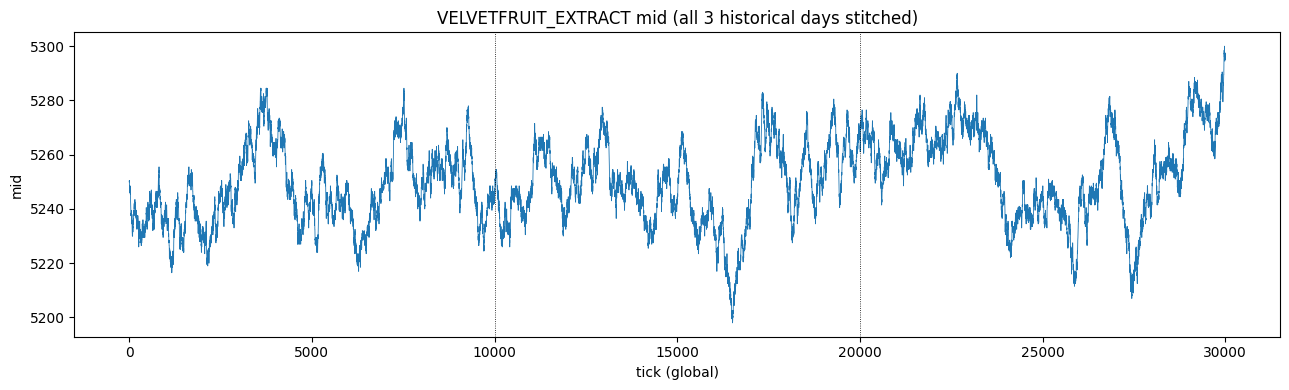

In [4]:
fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(mid.index, mid[UNDERLYING], lw=0.6, color='tab:blue')
ax.set_title('VELVETFRUIT_EXTRACT mid (all 3 historical days stitched)')
ax.set_ylabel('mid')
for d in DAYS[1:]:
    ax.axvline(d * TICKS_PER_DAY, color='k', ls=':', lw=0.6)
ax.set_xlabel('tick (global)')
plt.tight_layout(); plt.show()

## 2. Voucher mid prices vs. time

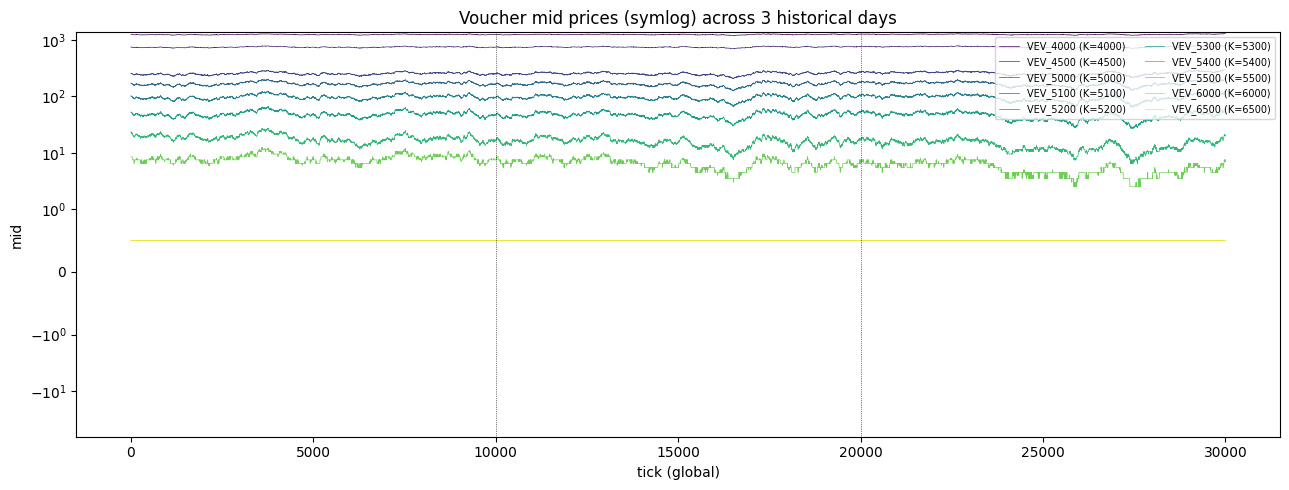

In [5]:
fig, ax = plt.subplots(figsize=(13, 5))
for sym, K in sorted_strikes:
    if sym in mid.columns:
        ax.plot(mid.index, mid[sym], lw=0.5, label=f'{sym} (K={K})', color=STRIKE_COLOR[sym])
for d in DAYS[1:]:
    ax.axvline(d * TICKS_PER_DAY, color='k', ls=':', lw=0.5)
ax.set_yscale('symlog', linthresh=1)
ax.set_title('Voucher mid prices (symlog) across 3 historical days')
ax.set_xlabel('tick (global)'); ax.set_ylabel('mid')
ax.legend(fontsize=7, ncol=2, loc='upper right')
plt.tight_layout(); plt.show()

## 3. Black-Scholes helpers and IV solver

In [6]:
SQRT2 = np.sqrt(2.0)

def _norm_cdf(x):
    return 0.5 * (1.0 + np.vectorize(erf)(x / SQRT2))

def _norm_pdf(x):
    return np.exp(-0.5 * np.asarray(x) ** 2) / np.sqrt(2 * np.pi)

def bs_call(S, K, T, sigma, r=0.0):
    """Black-Scholes call price. S,K > 0, T > 0, sigma > 0."""
    S = np.asarray(S, dtype=float)
    K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float)
    sigma = np.asarray(sigma, dtype=float)
    vt = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + 0.5 * vt * vt) / vt
    d2 = d1 - vt
    return S * _norm_cdf(d1) - K * np.exp(-r * T) * _norm_cdf(d2)

def bs_vega(S, K, T, sigma, r=0.0):
    S = float(S); K = float(K); T = float(T); sigma = float(sigma)
    vt = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + 0.5 * vt * vt) / vt
    return S * _norm_pdf(d1) * np.sqrt(T)

def bs_greeks(S, K, T, sigma, r=0.0):
    """Return (delta, gamma, theta_per_year, vega) for a call."""
    S = np.asarray(S, dtype=float); K = np.asarray(K, dtype=float)
    T = np.asarray(T, dtype=float); sigma = np.asarray(sigma, dtype=float)
    vt = sigma * np.sqrt(T)
    d1 = (np.log(S / K) + 0.5 * vt * vt) / vt
    d2 = d1 - vt
    delta = _norm_cdf(d1)
    pdf_d1 = _norm_pdf(d1)
    gamma = pdf_d1 / (S * vt)
    theta = -(S * pdf_d1 * sigma) / (2 * np.sqrt(T)) - r * K * np.exp(-r * T) * _norm_cdf(d2)
    vega = S * pdf_d1 * np.sqrt(T)
    return delta, gamma, theta, vega

def implied_vol_call(price, S, K, T, r=0.0, lo=1e-4, hi=3.0, tol=1e-8,
                    max_iter=80, vega_min=10.0, tick=0.5):
    """Robust IV solver - bisection bracket + Newton polish.

    Rejects with NaN when the quote gives no information about sigma:
    - price below intrinsic (arbitrage-violating or stale quote),
    - price <= 0 or non-finite,
    - price above the sigma=hi BS call value (off-the-chart IV),
    - price so close to intrinsic that bs_call is effectively flat in sigma
      near lo (the BS curve has zero curvature there, any sigma fits),
    - **price at or below the tick floor** (pure quantisation, no IV info),
    - **local vega too small** relative to tick size: if vega < vega_min,
      the 0.5-tick rounding implies IV uncertainty > tick/vega_min vol-pts,
      which is larger than any real smile signal. Kills far-OTM floor quotes
      (VEV_6000, VEV_6500) and unreliable near-OTM tails.
    """
    if not np.isfinite(price) or price <= 0:
        return np.nan
    if price <= tick + 1e-12:
        # Tick-floor quote — no information; any sigma below some threshold fits.
        return np.nan
    intrinsic = max(0.0, S - K * exp(-r * T))
    upper = float(bs_call(S, K, T, hi, r))
    if price < intrinsic - 1e-8:
        return np.nan
    if price > upper:
        return np.nan
    lower_val = float(bs_call(S, K, T, lo, r))
    if price - lower_val < tol:
        return np.nan

    a, b = lo, hi
    for _ in range(max_iter):
        mid_s = 0.5 * (a + b)
        f = float(bs_call(S, K, T, mid_s, r)) - price
        if abs(f) < tol:
            a = b = mid_s
            break
        if f > 0:
            b = mid_s
        else:
            a = mid_s
    sigma = 0.5 * (a + b)
    for _ in range(3):
        v = bs_vega(S, K, T, sigma, r)
        if v < 1e-10:
            break
        diff = float(bs_call(S, K, T, sigma, r)) - price
        sigma -= diff / v
        if not (lo < sigma < hi):
            sigma = 0.5 * (a + b)
            break

    # Post-solve vega check: IV uncertainty ~ tick / vega. Reject if too large.
    v_final = bs_vega(S, K, T, sigma, r)
    if v_final < vega_min:
        return np.nan
    return sigma

print('ATM 5000/5000 1y @ 20% vol:', bs_call(5000, 5000, 1.0, 0.20))
print('Recovered IV (ATM):', implied_vol_call(bs_call(5000, 5000, 1.0, 0.20), 5000, 5000, 1.0))
print('Deep-ITM at intrinsic (should be NaN):',
      implied_vol_call(1250.0, 5250.0, 4000.0, 6/365))
print('Far-OTM 0.5 price (should be NaN — tick floor):',
      implied_vol_call(0.5, 5250.0, 6500.0, 6/365))
print('Far-OTM 1.5 price, low vega (should be NaN):',
      implied_vol_call(1.5, 5250.0, 6500.0, 6/365))
print('ATM 100 price (should be valid IV):',
      implied_vol_call(100.0, 5250.0, 5250.0, 7/365))


ATM 5000/5000 1y @ 20% vol: 398.27837277028993
Recovered IV (ATM): 0.20000000000000004
Deep-ITM at intrinsic (should be NaN): nan
Far-OTM 0.5 price (should be NaN — tick floor): nan
Far-OTM 1.5 price, low vega (should be NaN): 0.6991587590856638
ATM 100 price (should be valid IV): 0.34480162208314674


## 4. Per-tick IV surface

**Rigorous IV construction.** The solver `implied_vol_call` now:
- rejects quotes below intrinsic, above the sigma=3 BS price, or <= 0;
- **rejects near-intrinsic prices** where `bs_call(sigma=lo) ~= price` - there the call curve is flat in sigma, so any sigma in a wide range fits and the "IV" is meaningless;
- bisects to a tight price tolerance, then polishes with 3 Newton steps.

**Moneyness convention.** $m_t = \ln(S/K)/\sqrt{T}$. Note this includes $\sqrt{T}$, so the *same strike on different days* lands at slightly different $m$ because TTE drops 8d -> 7d -> 6d. We therefore also fit the smile **per day** in sec. 5 to check stability across TTE, not only a single pooled fit.

**Time unit.** `T_years = tte_days / 365` is a convention; the smile shape and the detrended deviations are invariant to this choice - only the *level* of sigma scales. Everything downstream (greeks, gamma scalping EV) stays consistent because we use the same T everywhere.

In [7]:
# Build long-format: one row per (t_global, strike) with S, K, C, T, IV, moneyness, extrinsic.
voucher_syms = [s for s in STRIKES if s in mid.columns]
S_series = mid[UNDERLYING]

tick_to_tte = (
    prices[['t_global', 'tte_days']].drop_duplicates('t_global').set_index('t_global')['tte_days']
)

DOWN = 10  # downsample to every 10th tick for IV-solver speed
idx = mid.index[::DOWN]

rows = []
for t in idx:
    S = S_series.get(t, np.nan)
    if not np.isfinite(S):
        continue
    tte_d = tick_to_tte.get(t, np.nan)
    if not np.isfinite(tte_d):
        continue
    T = float(tte_d) / 365.0
    for sym in voucher_syms:
        C = mid.at[t, sym] if sym in mid.columns else np.nan
        if not np.isfinite(C):
            continue
        K = STRIKES[sym]
        intrinsic = max(0.0, S - K)
        extrinsic = float(C) - intrinsic
        iv = implied_vol_call(float(C), float(S), float(K), T)
        m = np.log(S / K) / np.sqrt(T)
        rows.append((t, sym, K, S, float(C), T, m, iv, extrinsic))

ivdf = pd.DataFrame(rows, columns=['t_global', 'symbol', 'K', 'S', 'C', 'T', 'm', 'iv', 'extrinsic'])
ivdf['day'] = (ivdf['t_global'] // TICKS_PER_DAY).astype(int)

diag = ivdf.groupby('symbol').agg(
    n_obs=('iv', 'size'),
    n_iv_valid=('iv', lambda s: int(s.notna().sum())),
    iv_mean=('iv', 'mean'),
    iv_std=('iv', 'std'),
    extrinsic_mean=('extrinsic', 'mean'),
).reindex([s for s, _ in sorted_strikes])
print(f'Total rows: {len(ivdf)}  ({ivdf["iv"].notna().sum()} with valid IV after robust solver)')
print(diag)

Total rows: 30000  (18723 with valid IV after robust solver)
          n_obs  n_iv_valid   iv_mean    iv_std  extrinsic_mean
symbol                                                         
VEV_4000   3000         128  0.866198  0.081669        0.005333
VEV_4500   3000         598  0.441636  0.048154       -0.008833
VEV_5000   3000        2997  0.232830  0.008409        4.908833
VEV_5100   3000        3000  0.230697  0.007547       16.695000
VEV_5200   3000        3000  0.233304  0.006228       45.443167
VEV_5300   3000        3000  0.235791  0.005566       46.744000
VEV_5400   3000        3000  0.221131  0.007113       15.953500
VEV_5500   3000        3000  0.239831  0.006202        6.639833
VEV_6000   3000           0       NaN       NaN        0.500000
VEV_6500   3000           0       NaN       NaN        0.500000


## 5. Volatility smile - all strikes on one graph

Scatter of implied vol $v_t$ vs. moneyness $m_t$ across all strikes. A parabola is fitted to produce $\hat v_t$ - the "fair" IV given $m_t$.

**Rigorous outlier filter** applied per row, three criteria combined:
1. `iv` must be finite (the robust solver in sec. 3 already rejects near-intrinsic ambiguity).
2. `extrinsic > max(3.0, 0.003 * S)` - at least 3 SeaShells of time value, or 0.3% of S.
3. `C >= 2.0` - minimum premium; with 0.5-tick discretization, IV below this threshold is dominated by price quantization noise.

**Per-day fits vs. pooled fit.** Because $m_t$ includes $\sqrt{T}$ and TTE changes 8d->7d->6d across historical days, the same strike lands at different $m$ each day. We fit the parabola both per-day (to check smile stability across TTE) and pooled.

Kept 17815 / 30000 rows (59.4%) after K-restriction + extrinsic filter.
Rows kept per strike:
symbol
VEV_4000       0
VEV_4500       0
VEV_5000    2815
VEV_5100    3000
VEV_5200    3000
VEV_5300    3000
VEV_5400    3000
VEV_5500    3000
VEV_6000       0
VEV_6500       0
dtype: int64

Pooled fit (unweighted):  a=+0.0341  b=-0.0016  c=+0.2305
Pooled fit (vega-weighted): a=-0.0105  b=+0.0059  c=+0.2327
Day 0 (TTE=8d, vega-wtd): a=+0.0321  b=+0.0138  c=+0.2311
Day 1 (TTE=7d, vega-wtd): a=-0.0438  b=+0.0014  c=+0.2347
Day 2 (TTE=6d, vega-wtd): a=-0.0258  b=-0.0001  c=+0.2325


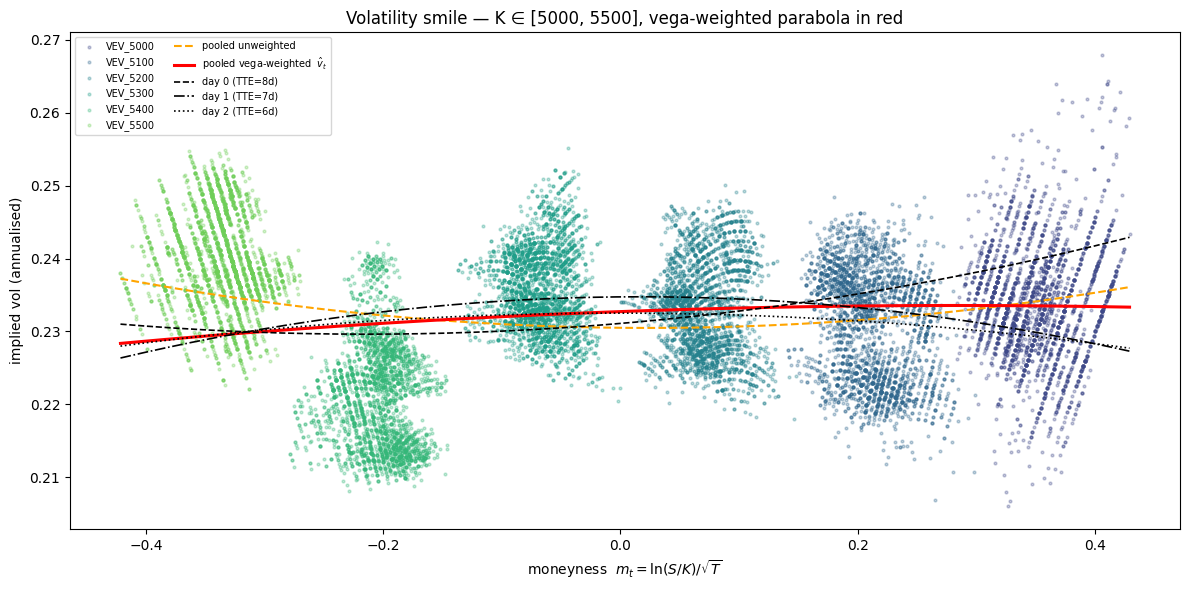

In [8]:
# Restrict to K in [5000, 5500] — outside this band strikes are either at
# intrinsic (4000/4500) or tick-floor pegged (6000/6500), contaminating the fit.
ATM_STRIKES = [5000, 5100, 5200, 5300, 5400, 5500]

def smile_mask(df):
    return (
        df['iv'].notna()
        & df['K'].isin(ATM_STRIKES)
        & (df['extrinsic'] > 2.0)   # need some time value for IV to be meaningful
        & (df['C'] >= 2.0)           # min premium above tick-quant noise
    )

mask = smile_mask(ivdf)
ivdf_clean = ivdf[mask].copy()
print(f'Kept {len(ivdf_clean)} / {len(ivdf)} rows '
      f'({100 * len(ivdf_clean) / len(ivdf):.1f}%) after K-restriction + extrinsic filter.')
print('Rows kept per strike:')
print(ivdf_clean.groupby('symbol').size().reindex([s for s, _ in sorted_strikes]).fillna(0).astype(int))

# Compute vega for each row (vectorized) — used as weight in the polyfit so that
# high-information ATM points dominate the fit.
_, _, _, vega_arr = bs_greeks(
    ivdf_clean['S'].values, ivdf_clean['K'].values,
    ivdf_clean['T'].values, ivdf_clean['iv'].values,
)
ivdf_clean['vega'] = vega_arr

# Unweighted (for comparison) and vega-weighted pooled fits
coef_unw = np.polyfit(ivdf_clean['m'], ivdf_clean['iv'], 2)
coef_vw = np.polyfit(ivdf_clean['m'], ivdf_clean['iv'], 2, w=ivdf_clean['vega'])

fit_by_day = {}
for d in DAYS:
    sub = ivdf_clean[ivdf_clean['day'] == d]
    if len(sub) < 10:
        continue
    fit_by_day[d] = np.polyfit(sub['m'], sub['iv'], 2, w=sub['vega'])

print(f"\nPooled fit (unweighted):  a={coef_unw[0]:+.4f}  b={coef_unw[1]:+.4f}  c={coef_unw[2]:+.4f}")
print(f"Pooled fit (vega-weighted): a={coef_vw[0]:+.4f}  b={coef_vw[1]:+.4f}  c={coef_vw[2]:+.4f}")
for d, c in fit_by_day.items():
    print(f"Day {d} (TTE={TTE_BY_DAY[d]}d, vega-wtd): a={c[0]:+.4f}  b={c[1]:+.4f}  c={c[2]:+.4f}")

fig, ax = plt.subplots(figsize=(12, 6))
for sym, K in sorted_strikes:
    sub = ivdf_clean[ivdf_clean['symbol'] == sym]
    if sub.empty:
        continue
    ax.scatter(sub['m'], sub['iv'], s=4, alpha=0.3, color=STRIKE_COLOR[sym], label=f'{sym}')

mgrid = np.linspace(ivdf_clean['m'].min(), ivdf_clean['m'].max(), 300)
ax.plot(mgrid, np.polyval(coef_unw, mgrid),
        color='orange', lw=1.5, ls='--', label='pooled unweighted')
ax.plot(mgrid, np.polyval(coef_vw, mgrid),
        color='red', lw=2.2, label='pooled vega-weighted  $\\hat v_t$')
day_styles = {0: '--', 1: '-.', 2: ':'}
for d, c in fit_by_day.items():
    ax.plot(mgrid, np.polyval(c, mgrid),
            color='black', lw=1.2, ls=day_styles.get(d, '--'),
            label=f'day {d} (TTE={TTE_BY_DAY[d]}d)')

ax.set_xlabel('moneyness  $m_t = \\ln(S/K)/\\sqrt{T}$')
ax.set_ylabel('implied vol (annualised)')
ax.set_title('Volatility smile — K ∈ [5000, 5500], vega-weighted parabola in red')
ax.legend(fontsize=7, ncol=2, loc='best')
plt.tight_layout(); plt.show()

coef = coef_vw  # downstream cells use vega-weighted fit


### Smile-fit diagnostics

Two sanity plots:
1. **Mean IV per strike** (with +/- 1 sigma bars). If all bars cluster tightly, the observed "smile" is really strike-to-strike level variation and the parabola is fitting mean-per-strike rather than within-strike curvature. The old strategy's edge comes from *residuals* around the fit, so what matters is the residual distribution being tight and mean-zero, not a dramatic smile.
2. **Residual histogram** $v_t - \hat v_t$. Should be roughly symmetric and centered on zero. Heavy tails or asymmetry = fit is biased and `iv_dev` signals would be unreliable.

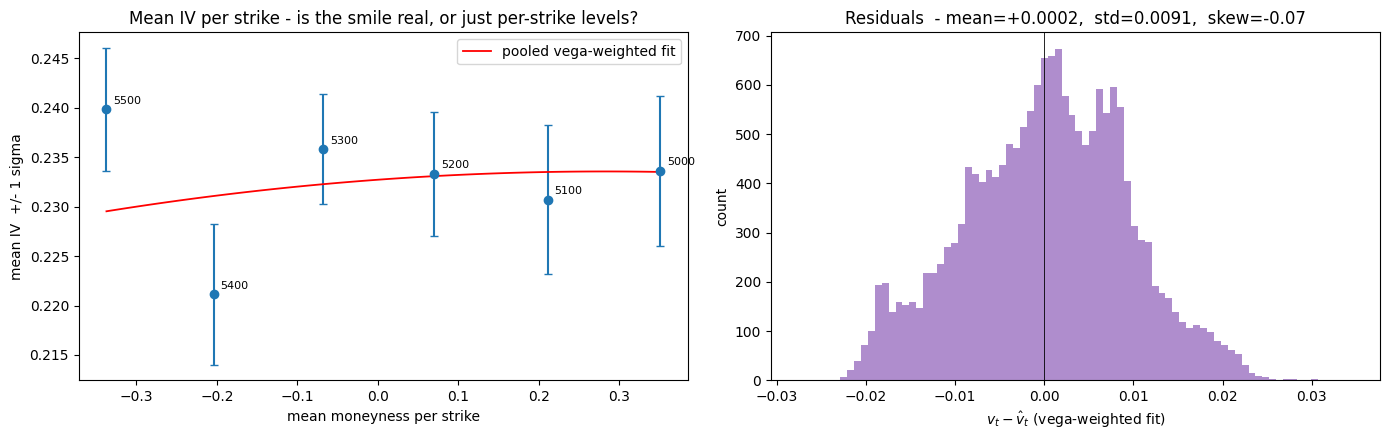


Mean-IV-per-strike summary:
             K     n    m_mean   iv_mean    iv_std
symbol                                            
VEV_5000  5000  2815  0.350592  0.233624  0.007573
VEV_5100  5100  3000  0.210807  0.230697  0.007547
VEV_5200  5200  3000  0.069863  0.233304  0.006228
VEV_5300  5300  3000 -0.068397  0.235791  0.005566
VEV_5400  5400  3000 -0.204072  0.221131  0.007113
VEV_5500  5500  3000 -0.337257  0.239831  0.006202


In [9]:
strike_stats = (
    ivdf_clean.groupby('symbol')
              .agg(m_mean=('m', 'mean'), iv_mean=('iv', 'mean'), iv_std=('iv', 'std'),
                   n=('iv', 'size'), K=('K', 'first'))
              .sort_values('K')
)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
ax.errorbar(strike_stats['m_mean'], strike_stats['iv_mean'],
            yerr=strike_stats['iv_std'], fmt='o', capsize=3, color='tab:blue')
for sym, row in strike_stats.iterrows():
    ax.annotate(sym.replace('VEV_', ''), (row['m_mean'], row['iv_mean']),
                textcoords='offset points', xytext=(5, 4), fontsize=8)
mgrid = np.linspace(strike_stats['m_mean'].min(), strike_stats['m_mean'].max(), 100)
ax.plot(mgrid, np.polyval(coef_vw, mgrid), color='red', lw=1.3, label='pooled vega-weighted fit')
ax.set_xlabel('mean moneyness per strike'); ax.set_ylabel('mean IV  +/- 1 sigma')
ax.set_title('Mean IV per strike - is the smile real, or just per-strike levels?')
ax.legend()

ivdf_clean['iv_resid_pool'] = ivdf_clean['iv'] - np.polyval(coef_vw, ivdf_clean['m'])
ax = axes[1]
ax.hist(ivdf_clean['iv_resid_pool'], bins=80, color='tab:purple', alpha=0.75)
ax.axvline(0, color='k', lw=0.6)
ax.set_xlabel('$v_t - \\hat v_t$ (vega-weighted fit)'); ax.set_ylabel('count')
r = ivdf_clean['iv_resid_pool']
ax.set_title(f'Residuals  - mean={r.mean():+.4f},  std={r.std():.4f},  skew={r.skew():+.2f}')
plt.tight_layout(); plt.show()

print('\nMean-IV-per-strike summary:')
print(strike_stats[['K', 'n', 'm_mean', 'iv_mean', 'iv_std']])

### TTE extrapolation to live (5 days)

All historical data covers TTE ∈ {8, 7, 6} days. Live Round 3 starts at **TTE = 5d**, outside
the fit range. Smiles typically steepen as $T \to 0$ (fat-tail premium grows). We fit
$(a, b, c)$ linearly in TTE across the three historical days and extrapolate to 5d.

If the extrapolation is stable (small changes in a/b/c), the pooled fit is a fine live
baseline. If coefficients drift strongly with TTE, the live smile needs to be refit online
from the live order book.


coef        d=8        d=7        d=6    slope/d    d=5 (extrap)
a     +0.03208  -0.04376  -0.02577  +0.02892  -0.07033
b     +0.01376  +0.00144  -0.00013  +0.00695  -0.00887
c     +0.23110  +0.23474  +0.23251  -0.00071  +0.23420

Live TTE=5d extrapolated coefs: a=-0.0703  b=-0.0089  c=+0.2342


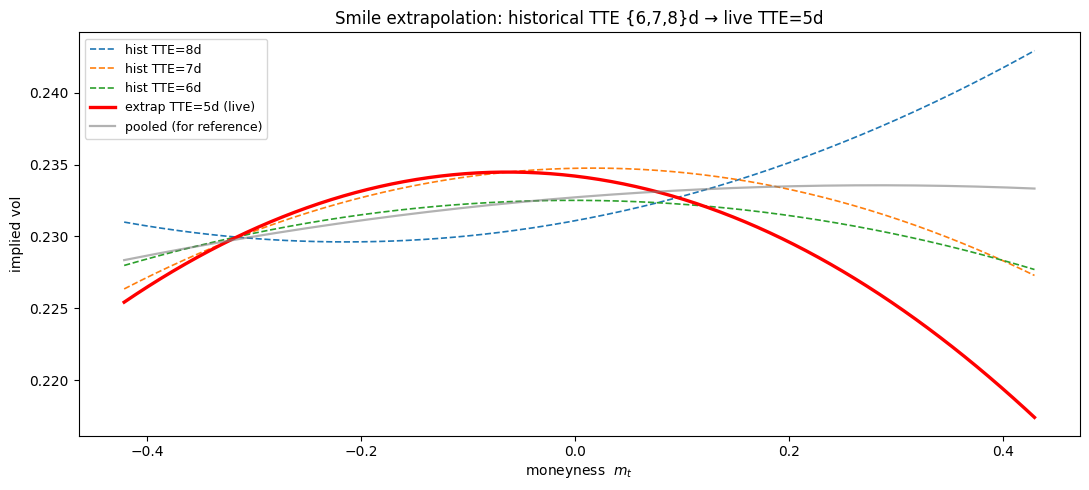

In [10]:
# Extrapolate per-day smile coefficients to live TTE = 5 days.
tte_hist = np.array([TTE_BY_DAY[d] for d in sorted(fit_by_day.keys())])
coefs_hist = np.vstack([fit_by_day[d] for d in sorted(fit_by_day.keys())])  # (n_days, 3)

def linreg_extrap(ys, xs, x_new):
    """Linear fit y = m*x + b across historical points, return value at x_new."""
    m, b = np.polyfit(xs, ys, 1)
    return m * x_new + b, m, b

LIVE_TTE = 5
coef_5d = np.zeros(3)
print(f"{'coef':<4}  {'d=8':>9}  {'d=7':>9}  {'d=6':>9}  {'slope/d':>9}  {'d=5 (extrap)':>14}")
for i, name in enumerate(['a', 'b', 'c']):
    val_5d, slope, intercept = linreg_extrap(coefs_hist[:, i], tte_hist, LIVE_TTE)
    coef_5d[i] = val_5d
    print(f"{name:<4}  {coefs_hist[0,i]:+.5f}  {coefs_hist[1,i]:+.5f}  {coefs_hist[2,i]:+.5f}  "
          f"{slope:+.5f}  {val_5d:+.5f}")

print(f"\nLive TTE=5d extrapolated coefs: a={coef_5d[0]:+.4f}  b={coef_5d[1]:+.4f}  c={coef_5d[2]:+.4f}")

# Plot: historical fits + extrapolated live fit on same axis.
fig, ax = plt.subplots(figsize=(11, 5))
mgrid = np.linspace(ivdf_clean['m'].min(), ivdf_clean['m'].max(), 300)
for d, c in fit_by_day.items():
    ax.plot(mgrid, np.polyval(c, mgrid), lw=1.2, ls='--',
            label=f'hist TTE={TTE_BY_DAY[d]}d')
ax.plot(mgrid, np.polyval(coef_5d, mgrid), lw=2.4, color='red',
        label=f'extrap TTE={LIVE_TTE}d (live)')
ax.plot(mgrid, np.polyval(coef_vw, mgrid), lw=1.6, color='gray', alpha=0.6,
        label='pooled (for reference)')
ax.set_xlabel('moneyness  $m_t$'); ax.set_ylabel('implied vol')
ax.set_title(f'Smile extrapolation: historical TTE {{6,7,8}}d → live TTE={LIVE_TTE}d')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

# Save for downstream use if the user wants to compute deviations using the live-projected smile.
coef_live = coef_5d


## 6. IV deviations $v_t - \hat v_t$ â€” all strikes on one graph

After subtracting the fitted smile, residuals are moneyness-independent. Short-term patterns here = relative option mispricing signal. Each strike is plotted in its own color on a shared axis.

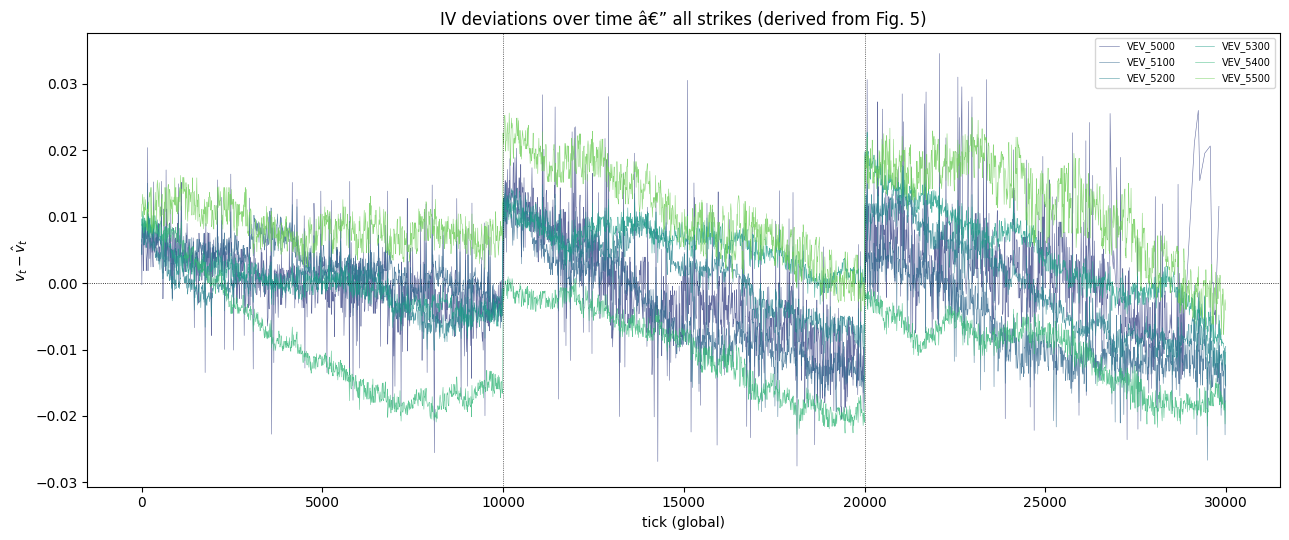

Summary per strike (iv_dev):
           count      mean       std
symbol                              
VEV_4000     NaN       NaN       NaN
VEV_4500     NaN       NaN       NaN
VEV_5000  2815.0  0.000122  0.007579
VEV_5100  3000.0 -0.002803  0.007557
VEV_5200  3000.0  0.000222  0.006230
VEV_5300  3000.0  0.003525  0.005574
VEV_5400  3000.0 -0.009942  0.007138
VEV_5500  3000.0  0.010307  0.006259
VEV_6000     NaN       NaN       NaN
VEV_6500     NaN       NaN       NaN


In [11]:
ivdf_clean['iv_fit'] = np.polyval(coef, ivdf_clean['m'])
ivdf_clean['iv_dev'] = ivdf_clean['iv'] - ivdf_clean['iv_fit']

fig, ax = plt.subplots(figsize=(13, 5.5))
for sym, K in sorted_strikes:
    sub = ivdf_clean[ivdf_clean['symbol'] == sym].sort_values('t_global')
    if sub.empty:
        continue
    ax.plot(sub['t_global'], sub['iv_dev'], lw=0.4, alpha=0.8,
            color=STRIKE_COLOR[sym], label=f'{sym}')
ax.axhline(0, color='k', ls=':', lw=0.6)
for d in DAYS[1:]:
    ax.axvline(d * TICKS_PER_DAY, color='k', ls=':', lw=0.5)
ax.set_xlabel('tick (global)'); ax.set_ylabel('$v_t - \\hat v_t$')
ax.set_title('IV deviations over time â€” all strikes (derived from Fig. 5)')
ax.legend(fontsize=7, ncol=2, loc='best')
plt.tight_layout(); plt.show()

print('Summary per strike (iv_dev):')
print(ivdf_clean.groupby('symbol')['iv_dev'].agg(['count', 'mean', 'std']).reindex([s for s,_ in sorted_strikes]))

## 7. Price-space deviations â€” all strikes on one graph

Same IV deviations as Â§6, transformed into price space via Black-Scholes: $C_{\text{mkt}} - C(\hat v_t)$. More intuitive view of relative mispricings over time â€” units are SeaShells, directly comparable to quote sizes.

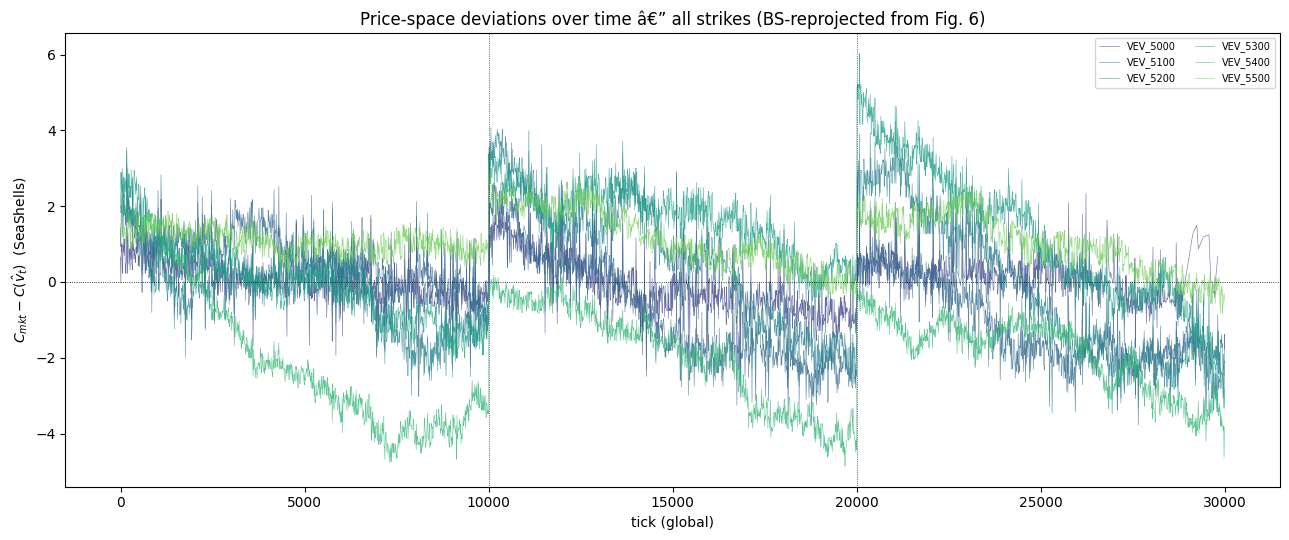

Summary per strike (C_dev):
           count      mean       std
symbol                              
VEV_4000     NaN       NaN       NaN
VEV_4500     NaN       NaN       NaN
VEV_5000  2815.0  0.025524  0.682684
VEV_5100  3000.0 -0.423683  1.381682
VEV_5200  3000.0  0.065847  1.644073
VEV_5300  3000.0  0.946608  1.515994
VEV_5400  3000.0 -1.935410  1.466233
VEV_5500  3000.0  1.087825  0.656628
VEV_6000     NaN       NaN       NaN
VEV_6500     NaN       NaN       NaN


In [12]:
ivdf_clean['C_fit'] = bs_call(
    ivdf_clean['S'].values, ivdf_clean['K'].values,
    ivdf_clean['T'].values, ivdf_clean['iv_fit'].values,
)
ivdf_clean['C_dev'] = ivdf_clean['C'] - ivdf_clean['C_fit']

fig, ax = plt.subplots(figsize=(13, 5.5))
for sym, K in sorted_strikes:
    sub = ivdf_clean[ivdf_clean['symbol'] == sym].sort_values('t_global')
    if sub.empty:
        continue
    ax.plot(sub['t_global'], sub['C_dev'], lw=0.4, alpha=0.8,
            color=STRIKE_COLOR[sym], label=f'{sym}')
ax.axhline(0, color='k', ls=':', lw=0.6)
for d in DAYS[1:]:
    ax.axvline(d * TICKS_PER_DAY, color='k', ls=':', lw=0.5)
ax.set_xlabel('tick (global)'); ax.set_ylabel('$C_{mkt} - C(\\hat v_t)$  (SeaShells)')
ax.set_title('Price-space deviations over time â€” all strikes (BS-reprojected from Fig. 6)')
ax.legend(fontsize=7, ncol=2, loc='best')
plt.tight_layout(); plt.show()

print('Summary per strike (C_dev):')
print(ivdf_clean.groupby('symbol')['C_dev'].agg(['count', 'mean', 'std']).reindex([s for s,_ in sorted_strikes]))

## 8. Underlying autocorrelation â€” mean-reversion check

Same test as old strategy: autocorrelation of VE returns vs. a random-normal baseline.

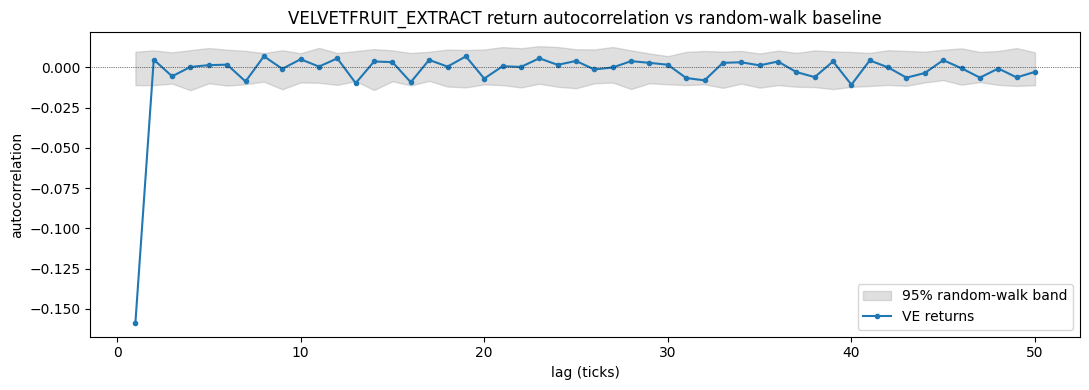

lag-1 autocorr: -0.1588
mean abs autocorr 1..10: 0.0194


In [13]:
rets = mid[UNDERLYING].pct_change().dropna()

def autocorr(x, lags):
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n = len(x)
    denom = np.dot(x, x)
    if denom == 0 or not np.isfinite(denom):
        return np.full(len(lags), np.nan)
    out = np.empty(len(lags))
    for i, k in enumerate(lags):
        if k <= 0 or k >= n:
            out[i] = np.nan
        else:
            out[i] = np.dot(x[:-k], x[k:]) / denom
    return out

lags = np.arange(1, 51)
ac_real = autocorr(rets.values, lags)

rng = np.random.default_rng(0)
baseline = np.array([
    autocorr(rng.normal(0, rets.std(), size=len(rets)), lags) for _ in range(100)
])
lo, hi = np.quantile(baseline, [0.025, 0.975], axis=0)

fig, ax = plt.subplots(figsize=(11, 4))
ax.fill_between(lags, lo, hi, color='gray', alpha=0.25, label='95% random-walk band')
ax.plot(lags, ac_real, marker='o', ms=3, color='tab:blue', label='VE returns')
ax.axhline(0, color='k', ls=':', lw=0.5)
ax.set_xlabel('lag (ticks)'); ax.set_ylabel('autocorrelation')
ax.set_title('VELVETFRUIT_EXTRACT return autocorrelation vs random-walk baseline')
ax.legend(); plt.tight_layout(); plt.show()

print(f'lag-1 autocorr: {ac_real[0]:+.4f}')
print(f'mean abs autocorr 1..10: {np.nanmean(np.abs(ac_real[:10])):.4f}')

## 9. Per-strike return autocorrelation (scalping signal check)

Old strategy relied on negative lag-1 autocorrelation in **call-price** returns as justification for IV scalping. Compute it per strike. Strikes with a flat price path (always near zero) produce NaN and are not scalpable.

In [14]:
rows = []
for sym, K in sorted_strikes:
    if sym not in mid.columns:
        continue
    series = mid[sym].dropna()
    if len(series) < 200:
        continue
    r = series.pct_change().dropna().values
    ac1 = autocorr(r, [1])[0]
    rows.append({'symbol': sym, 'K': K, 'n': len(r), 'ac_lag1': ac1})
ac_df = pd.DataFrame(rows).sort_values('K')
ac_df

,symbol,K,n,ac_lag1
0,VEV_4000,4000,29999,-0.284426
1,VEV_4500,4500,29999,-0.225129
2,VEV_5000,5000,29999,-0.099564
3,VEV_5100,5100,29999,-0.098016
4,VEV_5200,5200,29999,-0.134874
5,VEV_5300,5300,29999,-0.219789
6,VEV_5400,5400,29999,-0.249981
7,VEV_5500,5500,29999,-0.241230
8,VEV_6000,6000,29999,NaN
9,VEV_6500,6500,29999,NaN


### Subsampled return autocorrelation — bid-ask-bounce test

A single-lag negative autocorrelation on 1-tick mid returns is the textbook signature of
**bid-ask bounce**, not tradable mean reversion. Under pure bounce, the autocorrelation
decays to zero as we subsample every k-th tick (once k exceeds the typical holding period
of a single side). Under real mean reversion, it persists.

Test: compute lag-1 AC of **subsampled** returns at dt = 1, 5, 10, 50 for VE and every
voucher. If the AC drops from −0.15/−0.25 at dt=1 to ~0 at dt≥5, the signal is bounce.


             symbol      K   ac1_dt1   ac1_dt5  ac1_dt10  ac1_dt50
VELVETFRUIT_EXTRACT    NaN -0.158760 -0.050753 -0.004635 -0.095843
           VEV_4000 4000.0 -0.284426 -0.121403 -0.033763 -0.083256
           VEV_4500 4500.0 -0.225129 -0.088001 -0.012685 -0.075558
           VEV_5000 5000.0 -0.099564 -0.045790  0.006126 -0.074302
           VEV_5100 5100.0 -0.098016 -0.039534  0.005238 -0.074218
           VEV_5200 5200.0 -0.134874 -0.053454  0.000948 -0.068443
           VEV_5300 5300.0 -0.219789 -0.095610 -0.028961 -0.067430
           VEV_5400 5400.0 -0.249981 -0.167284 -0.064313 -0.095414
           VEV_5500 5500.0 -0.241230 -0.219421 -0.233557 -0.140096
           VEV_6000 6000.0       NaN       NaN       NaN       NaN
           VEV_6500 6500.0       NaN       NaN       NaN       NaN


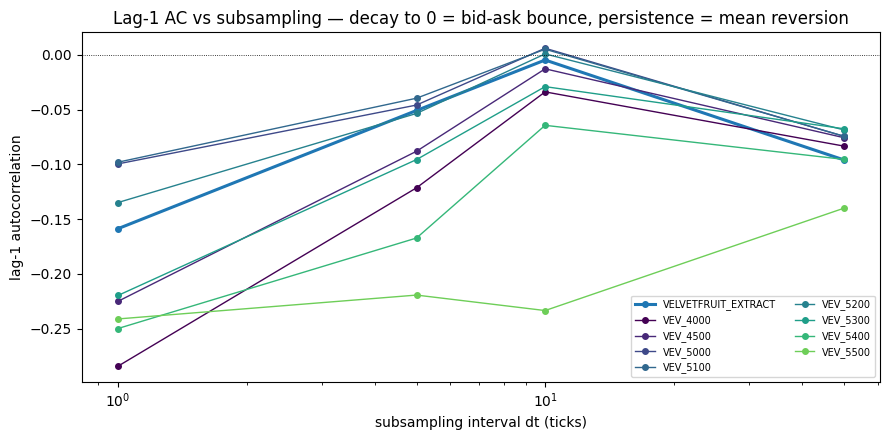


Interpretation:
  - If |ac1| at dt=1 is large and |ac1| at dt≥5 is near 0, the 1-tick signal is bid-ask bounce.
  - A real mean-reversion signal would persist (non-trivial AC) at dt=5 and dt=10.


In [15]:
# Subsampled lag-1 autocorrelation — decays to zero under bid-ask bounce.
SUB_DTS = [1, 5, 10, 50]

def lag1_ac_subsampled(series: pd.Series, dt: int) -> float:
    r = series.iloc[::dt].pct_change().dropna().values
    if len(r) < 20:
        return np.nan
    return autocorr(r, [1])[0]

rows = []
# Underlying VE
row = {'symbol': UNDERLYING, 'K': np.nan}
for dt in SUB_DTS:
    row[f'ac1_dt{dt}'] = lag1_ac_subsampled(mid[UNDERLYING].dropna(), dt)
rows.append(row)
# Each voucher
for sym, K in sorted_strikes:
    if sym not in mid.columns:
        continue
    row = {'symbol': sym, 'K': K}
    for dt in SUB_DTS:
        row[f'ac1_dt{dt}'] = lag1_ac_subsampled(mid[sym].dropna(), dt)
    rows.append(row)

ac_multi = pd.DataFrame(rows)
print(ac_multi.to_string(index=False))

# Visualise decay
fig, ax = plt.subplots(figsize=(9, 4.5))
for _, row in ac_multi.iterrows():
    vals = [row[f'ac1_dt{dt}'] for dt in SUB_DTS]
    if not np.all(np.isnan(vals)):
        color = 'tab:blue' if row['symbol'] == UNDERLYING else STRIKE_COLOR.get(row['symbol'], 'gray')
        lw = 2.2 if row['symbol'] == UNDERLYING else 1.0
        ax.plot(SUB_DTS, vals, '-o', ms=4, lw=lw, color=color, label=row['symbol'])
ax.axhline(0, color='k', ls=':', lw=0.6)
ax.set_xscale('log')
ax.set_xlabel('subsampling interval dt (ticks)')
ax.set_ylabel('lag-1 autocorrelation')
ax.set_title('Lag-1 AC vs subsampling — decay to 0 = bid-ask bounce, persistence = mean reversion')
ax.legend(fontsize=7, ncol=2, loc='best')
plt.tight_layout(); plt.show()

print('\nInterpretation:')
print('  - If |ac1| at dt=1 is large and |ac1| at dt≥5 is near 0, the 1-tick signal is bid-ask bounce.')
print('  - A real mean-reversion signal would persist (non-trivial AC) at dt=5 and dt=10.')


## 10. Gamma scalping â€” expected value

**Setup.** Buy 1 call, continuously delta-hedge by shorting $\Delta \cdot S$ of the underlying. The instantaneous P&L of this delta-neutral book is:

$$
d\Pi \;=\; \tfrac{1}{2}\,\Gamma\,(dS)^2 \;+\; \Theta\,dt
$$

(higher-order terms ignored; $\Theta$ is negative for a long option).

Taking expectations, $\mathbb{E}[(dS)^2] = \sigma_{\text{real}}^2 S^2 \, dt$, and under Black-Scholes $\Theta = -\tfrac{1}{2}\Gamma S^2 \sigma_{\text{impl}}^2$ (zero rates), giving:

$$
\mathbb{E}[d\Pi] \;=\; \tfrac{1}{2}\,\Gamma\,S^2\,(\sigma_{\text{real}}^2 - \sigma_{\text{impl}}^2)\,dt
$$

**Conclusion:** gamma scalping is **positive EV iff realised vol > implied vol**. The underlying price moves provide convexity gains that outweigh theta decay precisely when the market under-prices volatility.

### Realised vol estimate

In [16]:
# Annualisation: 1 Prosperity day = 1/365 year, so ticks/year = 10_000 * 365.
TICKS_PER_YEAR = TICKS_PER_DAY * 365

log_rets = np.log(mid[UNDERLYING]).diff().dropna()
sigma_tick = log_rets.std()
sigma_real_annual = sigma_tick * np.sqrt(TICKS_PER_YEAR)
print(f'Per-tick log-return std: {sigma_tick:.6f}')
print(f'Annualised realised vol (pooled 3 days): {sigma_real_annual:.4f}')

per_day = log_rets.groupby((log_rets.index // TICKS_PER_DAY).astype(int)).std() * np.sqrt(TICKS_PER_YEAR)
per_day.index.name = 'day'
per_day.name = 'sigma_realised_annual'
print('\nPer-day realised vol:')
print(per_day)

Per-tick log-return std: 0.000215
Annualised realised vol (pooled 3 days): 0.4117

Per-day realised vol:
day
0    0.408057
1    0.413111
2    0.413815
Name: sigma_realised_annual, dtype: float64


### Two-scale realised vol — microstructure-noise check

Per-day realised vol looked suspiciously flat (0.408 / 0.413 / 0.414) and suspiciously high
(~0.41) vs. an implied vol around 0.23. If the apparent "realised" is mostly 0.5-tick rounding
noise, the scalping edge is illusory.

The test: compute realised vol from *subsampled* returns at increasing intervals dt. Under
pure microstructure noise, $\sigma_\text{measured}^2 \approx \sigma_\text{true}^2 + \sigma_\text{noise}^2 / dt$.
So $\sigma(dt)$ should **decay and flatten** to the true $\sigma$ as dt grows. If it keeps
dropping, the estimator has not converged; if it plateaus early, microstructure is minor.


 dt_ticks  n_rets  sigma_per_dt  sigma_annual
        1   29999      0.000215      0.411656
        2   14999      0.000280      0.378155
        5    5999      0.000416      0.355525
       10    2999      0.000574      0.346829
       20    1499      0.000804      0.343565
       50     599      0.001280      0.345953
      100     299      0.001726      0.329726
      200     149      0.002214      0.299037
      500      59      0.003390      0.289619



Noise-model fit:  sigma_true (asymptote) = 0.3249
Noise coefficient (variance * dt): 0.068394
Naive 1-tick realised vol: 0.4117  ->   inflated by ~26.7% vs asymptote.


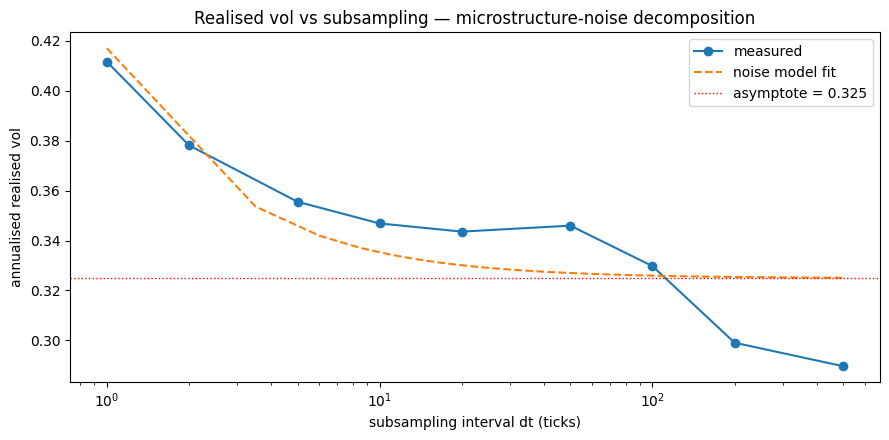


Updated sigma_real_annual for downstream edge calcs: 0.4117 -> 0.3249


In [17]:
# Two-scale realised vol: estimate at multiple subsampling intervals.
log_prices = np.log(mid[UNDERLYING])
DTS = [1, 2, 5, 10, 20, 50, 100, 200, 500]
rv_rows = []
for dt in DTS:
    rets = log_prices.iloc[::dt].diff().dropna()
    if len(rets) < 10:
        continue
    # Each subsample return covers dt ticks, so annualise with ticks/year ÷ dt.
    sigma_ann = rets.std() * np.sqrt(TICKS_PER_YEAR / dt)
    rv_rows.append({'dt_ticks': dt, 'n_rets': len(rets),
                    'sigma_per_dt': rets.std(), 'sigma_annual': sigma_ann})
rv_df = pd.DataFrame(rv_rows)
print(rv_df.to_string(index=False))

# Fit noise model: sigma_annual^2 = sigma_true^2 + C/dt  =>  y = a + b*(1/dt)
# a = sigma_true^2.  Use only dt where we still have enough samples.
fit_df = rv_df[rv_df['n_rets'] >= 30].copy()
y = fit_df['sigma_annual'].values ** 2
x = 1.0 / fit_df['dt_ticks'].values
A = np.vstack([np.ones_like(x), x]).T
(a_fit, b_fit), *_ = np.linalg.lstsq(A, y, rcond=None)
sigma_true = float(np.sqrt(max(a_fit, 0.0)))
noise_term = float(np.sqrt(max(b_fit, 0.0)))  # variance contribution per-1/dt-unit
print(f'\nNoise-model fit:  sigma_true (asymptote) = {sigma_true:.4f}')
print(f'Noise coefficient (variance * dt): {b_fit:.6f}')
print(f'Naive 1-tick realised vol: {rv_df.iloc[0]["sigma_annual"]:.4f}  ->  ',
      f'inflated by ~{100 * (rv_df.iloc[0]["sigma_annual"] / sigma_true - 1):.1f}% vs asymptote.')

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(rv_df['dt_ticks'], rv_df['sigma_annual'], 'o-', color='tab:blue', label='measured')
# Overlay noise-model curve
dt_grid = np.linspace(rv_df['dt_ticks'].min(), rv_df['dt_ticks'].max(), 200)
sigma_model = np.sqrt(a_fit + b_fit / dt_grid)
ax.plot(dt_grid, sigma_model, '--', color='tab:orange', label='noise model fit')
ax.axhline(sigma_true, color='red', lw=1, ls=':', label=f'asymptote = {sigma_true:.3f}')
ax.set_xscale('log')
ax.set_xlabel('subsampling interval dt (ticks)')
ax.set_ylabel('annualised realised vol')
ax.set_title('Realised vol vs subsampling — microstructure-noise decomposition')
ax.legend(); plt.tight_layout(); plt.show()

# Overwrite the pooled "realised vol" used downstream with the noise-corrected asymptote.
sigma_real_annual_raw = sigma_real_annual
sigma_real_annual = sigma_true
print(f'\nUpdated sigma_real_annual for downstream edge calcs: '
      f'{sigma_real_annual_raw:.4f} -> {sigma_real_annual:.4f}')


          sigma_impl_mean  sigma_realised      edge  edge_var     K
symbol                                                             
VEV_5000         0.233624        0.324865  0.091241  0.050957  5000
VEV_5100         0.230697        0.324865  0.094168  0.052316  5100
VEV_5200         0.233304        0.324865  0.091560  0.051106  5200
VEV_5300         0.235791        0.324865  0.089074  0.049940  5300
VEV_5400         0.221131        0.324865  0.103734  0.056638  5400
VEV_5500         0.239831        0.324865  0.085034  0.048018  5500


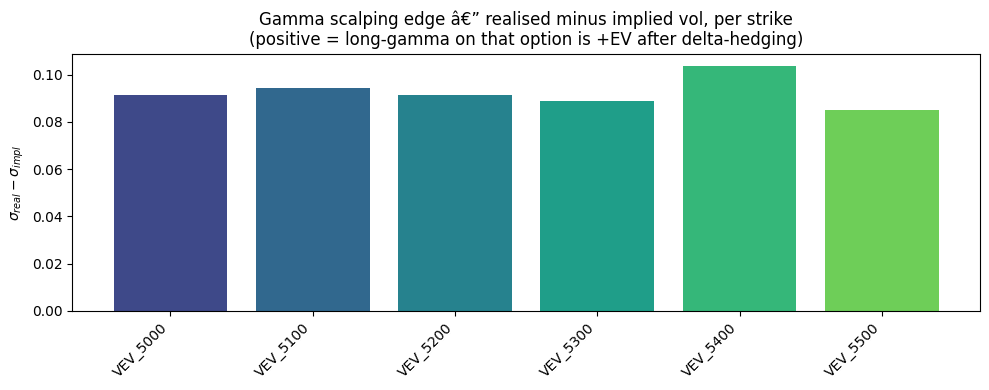

In [18]:
# Compare realised vs implied per strike (mean IV across ticks).
iv_mean = ivdf_clean.groupby('symbol')['iv'].mean().rename('sigma_impl_mean')
comp = pd.DataFrame({'sigma_impl_mean': iv_mean})
comp['sigma_realised'] = sigma_real_annual
comp['edge'] = comp['sigma_realised'] - comp['sigma_impl_mean']
comp['edge_var'] = comp['sigma_realised'] ** 2 - comp['sigma_impl_mean'] ** 2
comp['K'] = comp.index.map(STRIKES)
comp = comp.sort_values('K')
print(comp)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(comp)), comp['edge'], color=[STRIKE_COLOR[s] for s in comp.index])
ax.axhline(0, color='k', lw=0.6)
ax.set_xticks(range(len(comp)))
ax.set_xticklabels(comp.index, rotation=45, ha='right')
ax.set_ylabel(r'$\sigma_{real} - \sigma_{impl}$')
ax.set_title('Gamma scalping edge â€” realised minus implied vol, per strike\n(positive = long-gamma on that option is +EV after delta-hedging)')
plt.tight_layout(); plt.show()

### Pathwise EV estimate (tick-by-tick delta-hedged P&L)

Instead of the theoretical formula, simulate actual delta-hedged P&L tick-by-tick on the historical data. For each strike, hold 1 long call throughout. At every tick:
1. Compute delta using the **fitted** smile vol $\hat v_t$ (so the hedge doesn't chase IV noise).
2. Realise P&L of the call: $\Delta C$.
3. Realise P&L of the short-delta underlying hedge: $-\Delta_{t-1} \cdot \Delta S$.

Sum â†’ total gamma-scalping P&L per strike over 3 historical days, 1 contract.

     symbol       K  n_steps    pnl_sum  pnl_mean_per_step  pnl_std_per_step  avg_gamma  avg_theta_per_tick
0  VEV_5000  5000.0     2814   6.775509           0.002408          0.671740   0.000746           -0.000153
1  VEV_5100  5100.0     2999  11.543152           0.003849          0.601277   0.001541           -0.000317
2  VEV_5200  5200.0     2999  17.463732           0.005823          0.524520   0.002240           -0.000459
3  VEV_5300  5300.0     2999  16.116936           0.005374          0.424656   0.002275           -0.000464
4  VEV_5400  5400.0     2999  10.000759           0.003335          0.272467   0.001634           -0.000330
5  VEV_5500  5500.0     2999   6.407126           0.002136          0.280559   0.000836           -0.000167


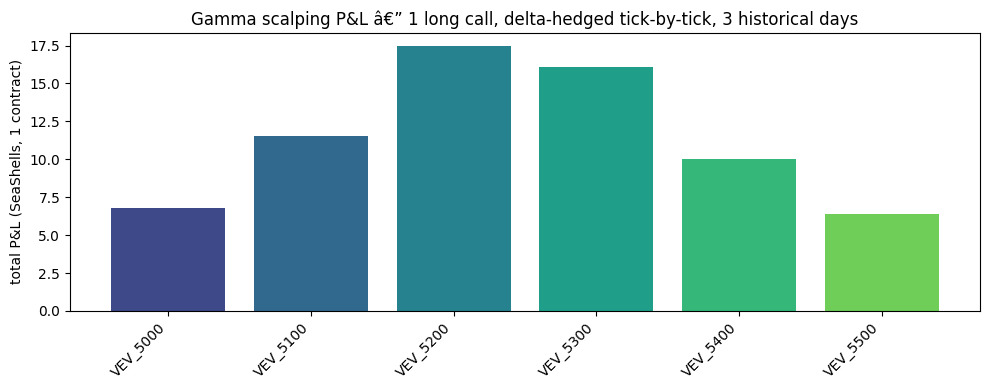

In [19]:
def gamma_scalp_pnl(sym):
    sub = ivdf_clean[ivdf_clean['symbol'] == sym].sort_values('t_global').reset_index(drop=True)
    if len(sub) < 10:
        return None
    S = sub['S'].values
    C = sub['C'].values
    T = sub['T'].values
    sig_hat = sub['iv_fit'].values
    K = float(sub['K'].iloc[0])
    delta, gamma, theta_y, vega = bs_greeks(S, K, T, sig_hat)
    dC = np.diff(C)
    dS = np.diff(S)
    hedge_delta = delta[:-1]  # hedge set before the move
    pnl_step = dC - hedge_delta * dS
    return {
        'symbol': sym, 'K': K, 'n_steps': len(pnl_step),
        'pnl_sum': float(np.nansum(pnl_step)),
        'pnl_mean_per_step': float(np.nanmean(pnl_step)),
        'pnl_std_per_step': float(np.nanstd(pnl_step)),
        'avg_gamma': float(np.nanmean(gamma)),
        'avg_theta_per_tick': float(np.nanmean(theta_y) / TICKS_PER_YEAR),
    }

rows = [r for r in (gamma_scalp_pnl(s) for s,_ in sorted_strikes) if r is not None]
pnl_df = pd.DataFrame(rows).sort_values('K').reset_index(drop=True)
print(pnl_df)

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(pnl_df)), pnl_df['pnl_sum'],
       color=[STRIKE_COLOR[s] for s in pnl_df['symbol']])
ax.axhline(0, color='k', lw=0.6)
ax.set_xticks(range(len(pnl_df))); ax.set_xticklabels(pnl_df['symbol'], rotation=45, ha='right')
ax.set_ylabel('total P&L (SeaShells, 1 contract)')
ax.set_title('Gamma scalping P&L â€” 1 long call, delta-hedged tick-by-tick, 3 historical days')
plt.tight_layout(); plt.show()

### Reading the gamma scalping result

- Strikes with `pnl_sum > 0` and low `pnl_std_per_step` are stable long-gamma candidates â€” small, consistent profits.
- If every strike's `pnl_sum` is near zero or negative, gamma scalping is not a standalone edge in this round's data.
- Compare the pathwise P&L to the theoretical $\tfrac{1}{2}\Gamma S^2 (\sigma_{real}^2 - \sigma_{impl}^2)$ edge above. Divergence = smile fit is biased, or VE doesn't behave lognormally (jumps, regime shifts).
- Position size in live play is constrained by the 300-per-voucher limit and the bid-ask cost of delta-hedging in VE (200 limit, has its own spread).

## Next steps

1. Confirm the smile fit is stable across days before relying on $\hat v_t$ as a signal.
2. Look at ATM-ish strikes first (closest to current S) â€” those match the old strategy's 10k focus.
3. Set scalping entry/exit thresholds on `C_dev` or `iv_dev`; backtest vs. a pure market-maker baseline.
4. If VE return autocorrelation is negative â†’ add a light EMA mean-reversion overlay on VE + deep-ITM voucher (highest-delta).